## 1. Import Required Libraries and Set Configuration

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer  # separate feature steps
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer  # missing values
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, LabelEncoder, label_binarize  # scaling + encoding
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score,  # evaluation metrics
                              f1_score, roc_auc_score, roc_curve, silhouette_score,
                              adjusted_rand_score, normalized_mutual_info_score, classification_report)
from scipy.stats import chi2_contingency
from scipy.optimize import linear_sum_assignment

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
RANDOM_STATE = 42

In [ ]:
DATA_PATH = '/content/drive/MyDrive/18.csv'
dataset = pd.read_csv(DATA_PATH)
dataset.head(10)

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A
5,461319,Male,Yes,56,No,Artist,0.0,Average,2.0,Cat_6,C
6,460156,Male,No,32,Yes,Healthcare,1.0,Low,3.0,Cat_6,C
7,464347,Female,No,33,Yes,Healthcare,1.0,Low,3.0,Cat_6,D
8,465015,Female,Yes,61,Yes,Engineer,0.0,Low,3.0,Cat_7,D
9,465176,Female,Yes,55,Yes,Artist,1.0,Average,4.0,Cat_6,C


## 2. Dataset Description

In [ ]:
print(dataset.shape)
dataset.info()

(8068, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [ ]:
class_counts = dataset['Segmentation'].value_counts()  # class counts
class_pct = dataset['Segmentation'].value_counts(normalize=True) * 100  # class percentages
imbalance_df = pd.DataFrame({'count': class_counts, 'percentage': class_pct.round(2)}).sort_index()
imbalance_df

,count,percentage
Segmentation,,
A,1972,24.44
B,1858,23.03
C,1970,24.42
D,2268,28.11


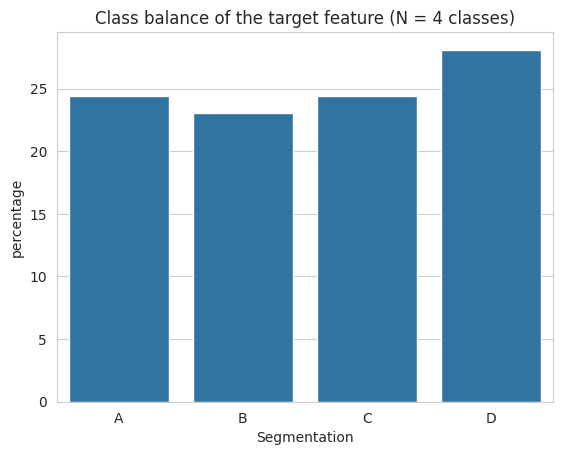

In [ ]:
plt.figure()
sns.barplot(x=imbalance_df.index, y=imbalance_df['percentage'])
plt.ylabel('percentage'); plt.xlabel('Segmentation')
plt.title('Class balance of the target feature (N = 4 classes)')
plt.show()

## 3. Data Analysis

In [ ]:
numerical_data = dataset.select_dtypes(include='number')  # numerical features
numerical_features = numerical_data.columns.tolist()
print(numerical_features)

['ID', 'Age', 'Work_Experience', 'Family_Size']


In [ ]:
categorical_data = dataset.select_dtypes(include='object')  # categorical features
categorical_features = categorical_data.columns.tolist()
print(categorical_features)

['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1', 'Segmentation']


In [ ]:
numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,8068.0,463479.214551,2595.381232,458982.0,461240.75,463472.5,465744.25,467974.0
Age,8068.0,43.466906,16.711696,18.0,30.00,40.0,53.00,89.0
Work_Experience,7239.0,2.641663,3.406763,0.0,0.00,1.0,4.00,14.0
Family_Size,7733.0,2.850123,1.531413,1.0,2.00,3.0,4.00,9.0


In [ ]:
categorical_data.describe().T

,count,unique,top,freq
Gender,8068,2,Male,4417
Ever_Married,7928,2,Yes,4643
Graduated,7990,2,Yes,4968
Profession,7944,9,Artist,2516
Spending_Score,8068,3,Low,4878
Var_1,7992,7,Cat_6,5238
Segmentation,8068,4,D,2268


In [ ]:
numerical_data.var()

,0
ID,6.736004e+06
Age,2.792808e+02
Work_Experience,1.160603e+01
Family_Size,2.345227e+00


In [ ]:
numerical_data.skew()

,0
ID,0.002435
Age,0.696021
Work_Experience,1.306226
Family_Size,1.010804


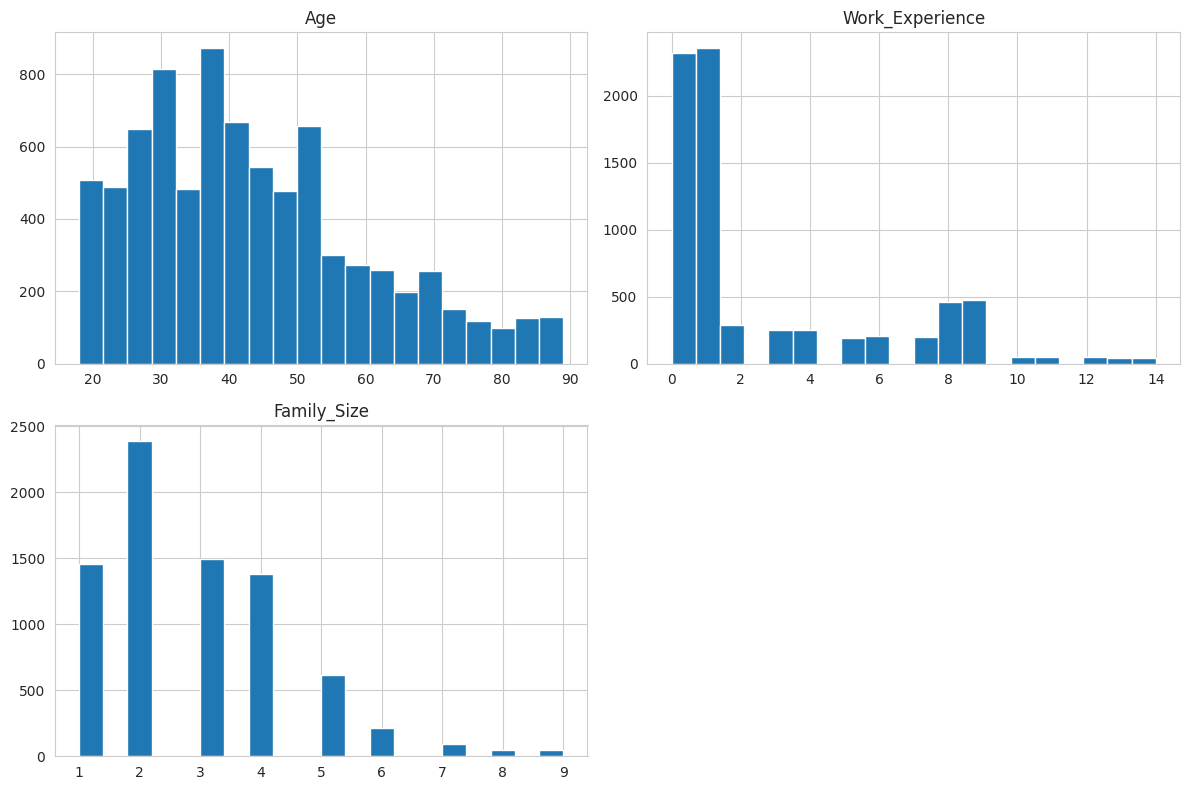

In [ ]:
numerical_data.drop(columns=['ID']).hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

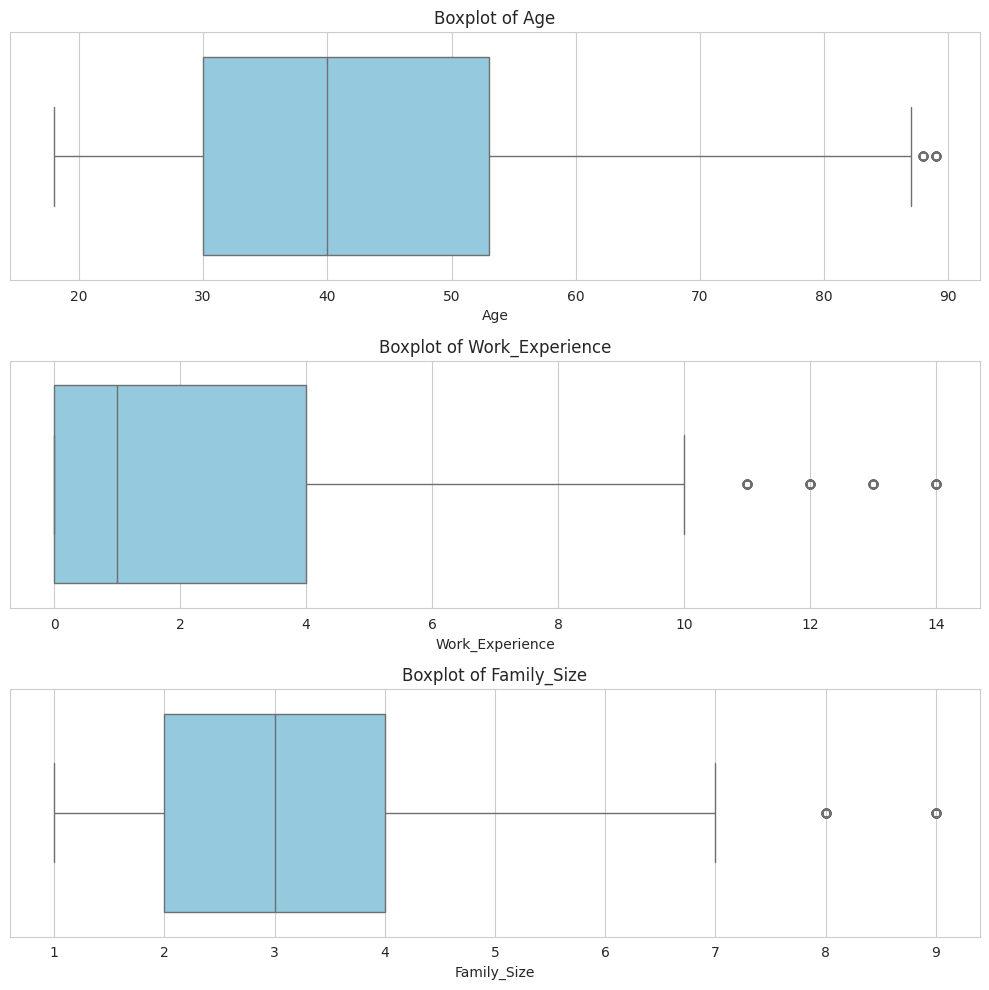

In [ ]:
plt.figure(figsize=(10, 10))
num_cols = numerical_data.drop(columns=['ID']).columns
for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 1, i)
    sns.boxplot(x=numerical_data[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
dataset.nunique()

,0
ID,8068
Gender,2
Ever_Married,2
Age,67
Graduated,2
Profession,9
Work_Experience,15
Spending_Score,3
Family_Size,9
Var_1,7


In [ ]:
dataset.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,140
Age,0
Graduated,78
Profession,124
Work_Experience,829
Spending_Score,0
Family_Size,335
Var_1,76


In [ ]:
categorical_data.nunique()

,0
Gender,2
Ever_Married,2
Graduated,2
Profession,9
Spending_Score,3
Var_1,7
Segmentation,4


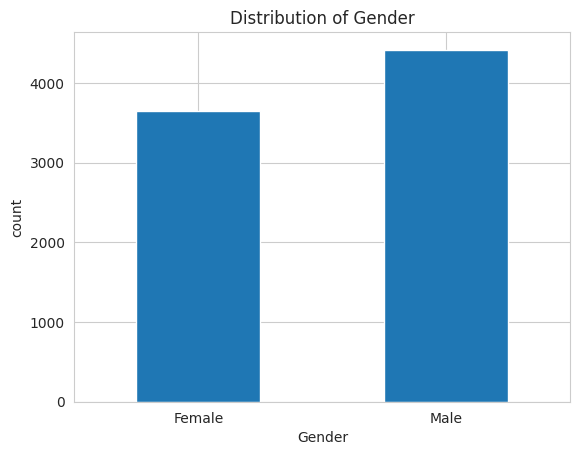

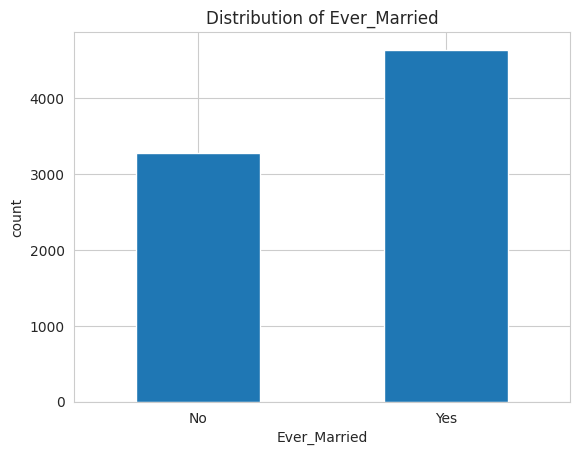

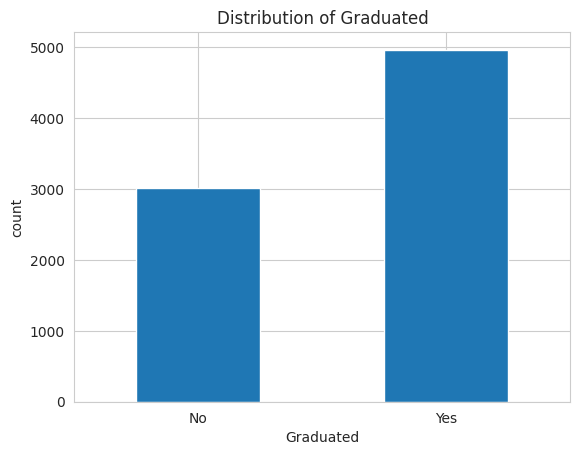

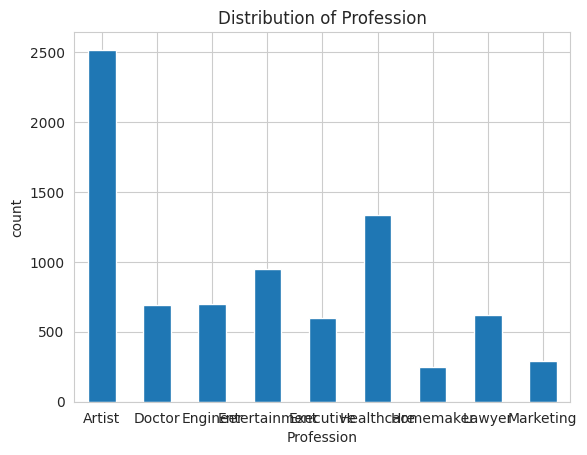

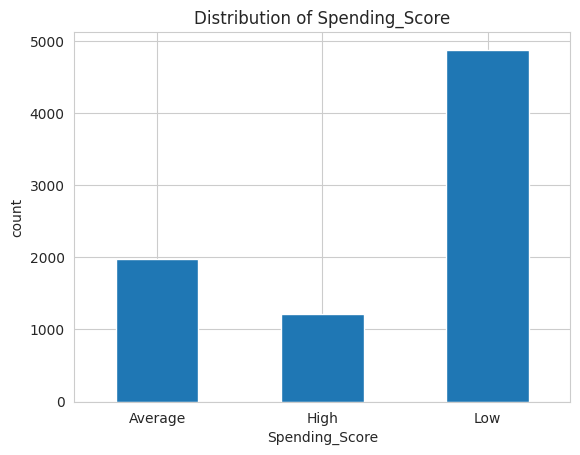

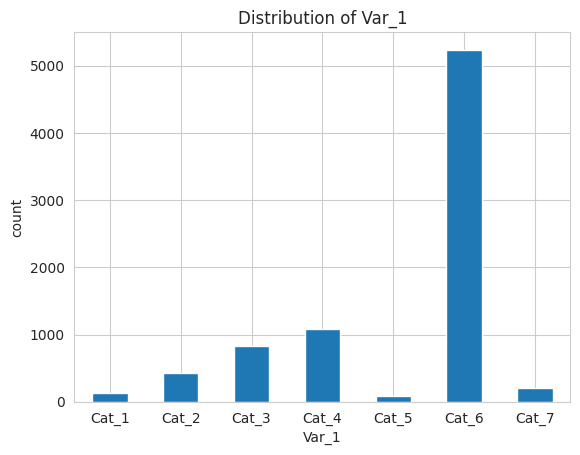

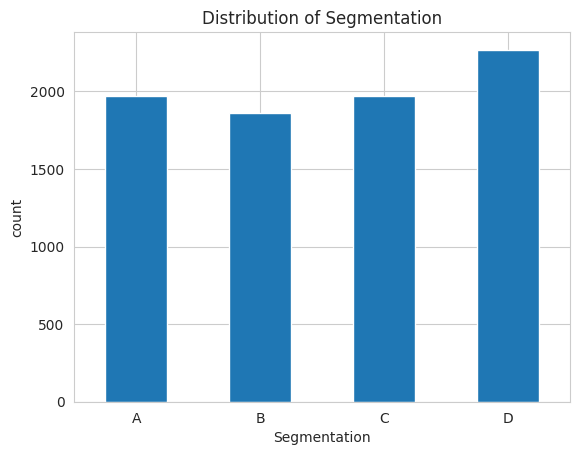

In [ ]:
for col in categorical_features:
    plt.figure()
    plt.title(f'Distribution of {col}')
    categorical_data[col].value_counts().sort_index().plot(kind='bar', rot=0, xlabel=col, ylabel='count')
    plt.show()

In [ ]:
correlation_matrix = numerical_data.drop(columns=['ID']).corr()  # numeric correlation
correlation_matrix

,Age,Work_Experience,Family_Size
Age,1.000000,-0.190789,-0.280517
Work_Experience,-0.190789,1.000000,-0.063234
Family_Size,-0.280517,-0.063234,1.000000


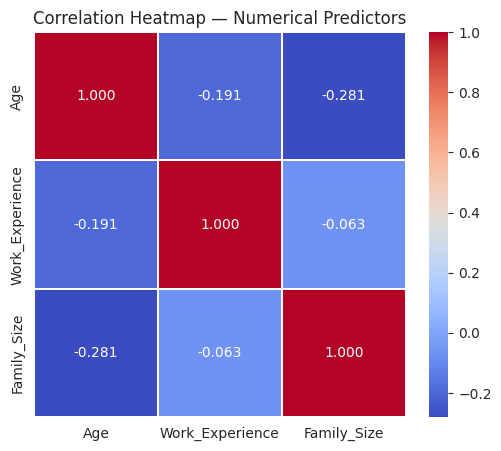

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.3)
plt.title('Correlation Heatmap — Numerical Predictors')
plt.show()

              mean  median
Segmentation              
A             44.9    41.0
B             48.2    46.0
C             49.1    49.0
D             33.4    29.0


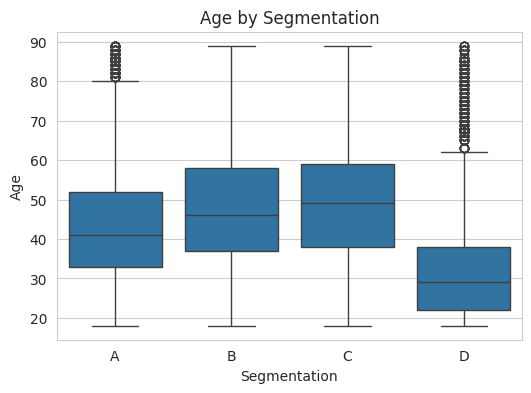

In [ ]:
print(dataset.groupby('Segmentation')['Age'].agg(['mean', 'median']).round(1))

plt.figure(figsize=(6, 4))
sns.boxplot(data=dataset, x='Segmentation', y='Age', order=['A', 'B', 'C', 'D'])
plt.title('Age by Segmentation')
plt.show()

Ever_Married    No   Yes
Segmentation            
A             41.3  58.7
B             26.2  73.8
C             20.4  79.6
D             72.5  27.5


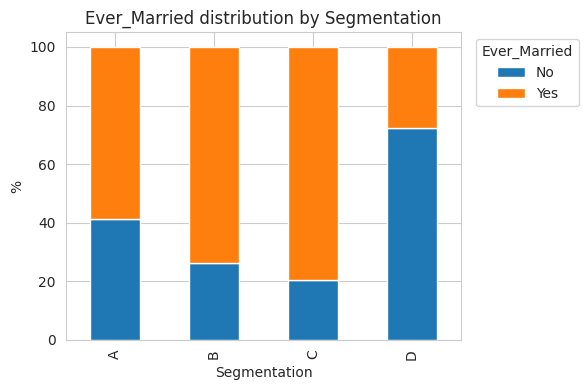

Graduated       No   Yes
Segmentation            
A             37.4  62.6
B             27.6  72.4
C             17.8  82.2
D             64.0  36.0


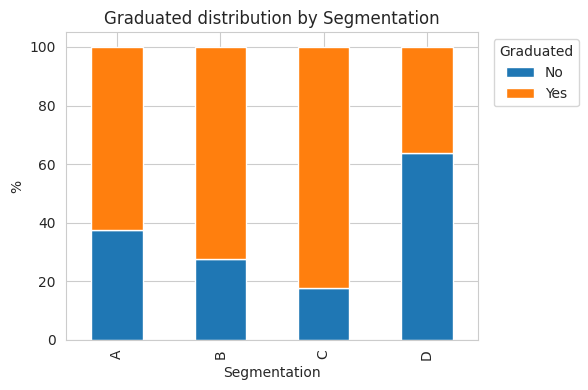

Spending_Score  Average  High   Low
Segmentation                       
A                  17.4  13.7  68.9
B                  31.8  20.7  47.6
C                  45.8  20.6  33.6
D                   6.1   6.9  87.0


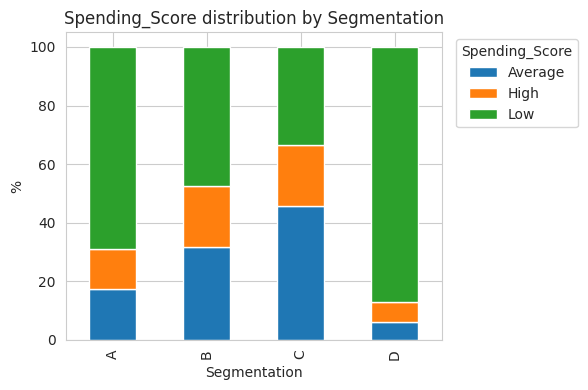

In [ ]:
for col in ['Ever_Married', 'Graduated', 'Spending_Score']:
    ct = pd.crosstab(dataset['Segmentation'], dataset[col], normalize='index') * 100  # compare by segment
    print(ct.round(1))
    ct.plot(kind='bar', stacked=True, figsize=(6, 4))
    plt.title(f'{col} distribution by Segmentation')
    plt.ylabel('%')
    plt.legend(title=col, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

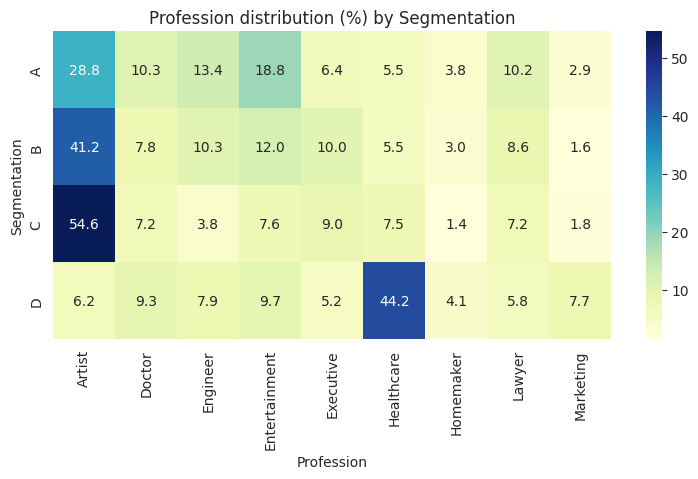

In [ ]:
profession_ct = pd.crosstab(dataset['Segmentation'], dataset['Profession'], normalize='index') * 100  # profession vs segment
plt.figure(figsize=(9, 4))
sns.heatmap(profession_ct.round(1), annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Profession distribution (%) by Segmentation')
plt.show()

              Work_Experience  Family_Size
Segmentation                              
A                         1.0          2.0
B                         1.0          2.0
C                         1.0          3.0
D                         1.0          3.0


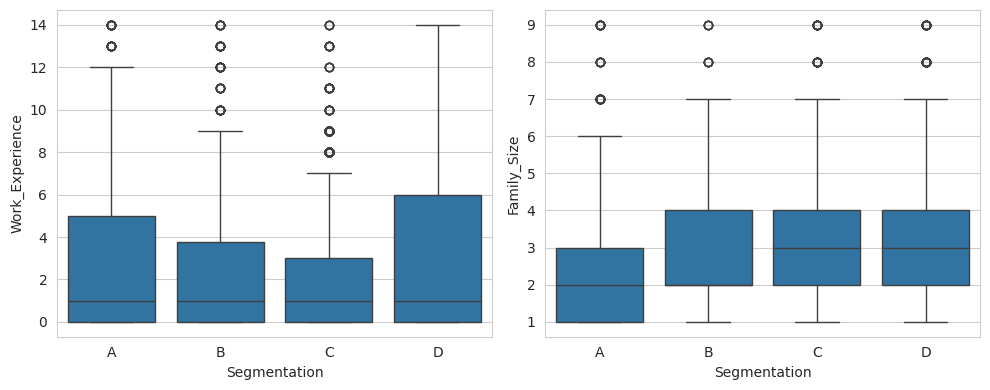

In [ ]:
print(dataset.groupby('Segmentation')[['Work_Experience', 'Family_Size']].median())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=dataset, x='Segmentation', y='Work_Experience', order=['A','B','C','D'], ax=axes[0])
sns.boxplot(data=dataset, x='Segmentation', y='Family_Size', order=['A','B','C','D'], ax=axes[1])
plt.tight_layout()
plt.show()

Ever_Married      0.422
Graduated         0.365
Profession        0.336
Spending_Score    0.307
Var_1             0.101
Gender            0.038
dtype: float64


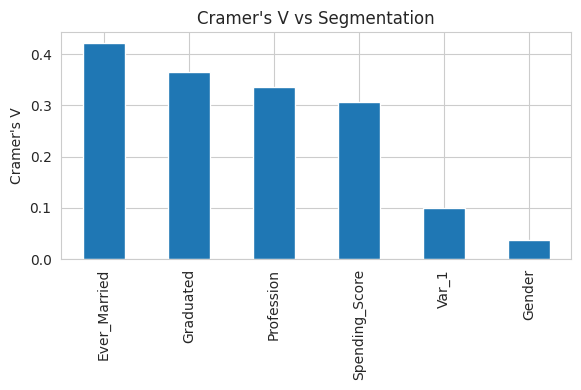

In [ ]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]  # chi-square value
    n = ct.sum().sum()
    r, k = ct.shape
    return float(np.sqrt((chi2 / n) / min(r - 1, k - 1)))

cat_predictors = ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']
cramers_results = {}
for c in cat_predictors:
    valid = dataset[[c, 'Segmentation']].dropna()  # ignore missing rows
    cramers_results[c] = cramers_v(valid[c], valid['Segmentation'])

cramers_series = pd.Series(cramers_results).sort_values(ascending=False)
print(cramers_series.round(3))

plt.figure(figsize=(6, 4))
cramers_series.plot(kind='bar')
plt.ylabel("Cramer's V")
plt.title("Cramer's V vs Segmentation")
plt.tight_layout()
plt.show()

## 4. Dataset Pre-processing

In [ ]:
print(dataset.duplicated().sum())  # exact duplicates
print(dataset.drop(columns=['ID']).duplicated().sum())

0
417


In [ ]:
TARGET = 'Segmentation'
IDENTIFIER = 'ID'

X = dataset.drop(columns=[TARGET, IDENTIFIER])  # remove target and ID
target_encoder = LabelEncoder()  # encode target labels
y_encoded = target_encoder.fit_transform(dataset[TARGET])  # A-D to numbers

print(list(target_encoder.classes_))
print(X.shape, y_encoded.shape)

['A', 'B', 'C', 'D']
(8068, 9) (8068,)


In [ ]:
numeric_features = ['Age', 'Work_Experience', 'Family_Size']
nominal_features = ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Var_1']
ordinal_features = ['Spending_Score']

def make_preprocessor():
    numeric_tf = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),  # fill numeric nulls
        ('scaler', StandardScaler())  # feature scaling
    ])
    nominal_tf = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # categorical encoding
    ])
    ordinal_tf = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ordinal', OrdinalEncoder(categories=[['Low', 'Average', 'High']]))  # ordered encoding
    ])
    return ColumnTransformer([
        ('num', numeric_tf, numeric_features),
        ('nom', nominal_tf, nominal_features),
        ('ord', ordinal_tf, ordinal_features)
    ])

## 5. Dataset Splitting

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=RANDOM_STATE, stratify=y_encoded)  # 80/20 stratified split

print(X_train.shape, X_test.shape)

(6454, 9) (1614, 9)


## 6. Model Training & Testing (Supervised)

In [ ]:
model_defs = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),  # logistic regression
    'KNN': KNeighborsClassifier(n_neighbors=15),  # KNN, 15 neighbours
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),  # decision tree
    'Neural Network (MLP)': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000,  # neural network
                                           random_state=RANDOM_STATE, early_stopping=True)
}

trained_pipelines = {}
for name, clf in model_defs.items():
    pipe = Pipeline([('preprocessor', make_preprocessor()), ('classifier', clf)])
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe
    print('Trained:', name)

Trained: Logistic Regression
Trained: KNN
Trained: Decision Tree
Trained: Neural Network (MLP)


## 7. Model Selection / Comparison Analysis

===== Logistic Regression =====
              precision    recall  f1-score   support

           A       0.41      0.44      0.43       394
           B       0.43      0.21      0.28       372
           C       0.51      0.62      0.56       394
           D       0.64      0.74      0.69       454

    accuracy                           0.52      1614
   macro avg       0.50      0.50      0.49      1614
weighted avg       0.50      0.52      0.50      1614

Accuracy 0.5161 | Macro-P 0.4969 | Macro-R 0.5034 | Macro-F1 0.4880 | Macro-AUC 0.7636


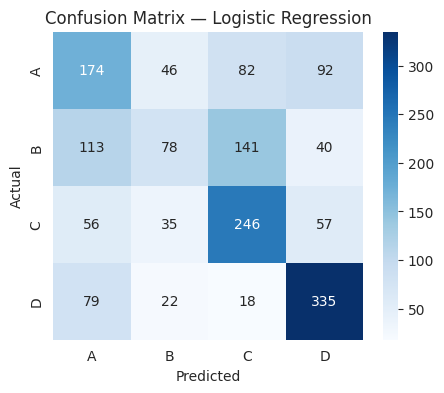

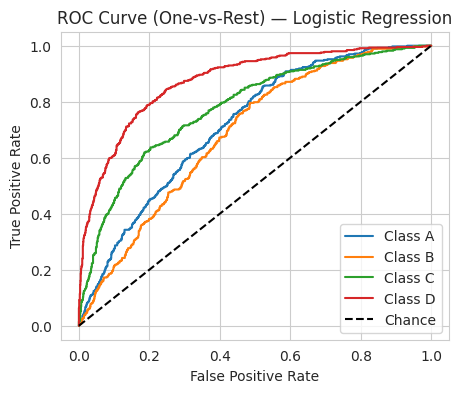

===== KNN =====
              precision    recall  f1-score   support

           A       0.41      0.44      0.42       394
           B       0.41      0.33      0.37       372
           C       0.55      0.56      0.56       394
           D       0.64      0.68      0.66       454

    accuracy                           0.51      1614
   macro avg       0.50      0.50      0.50      1614
weighted avg       0.51      0.51      0.51      1614

Accuracy 0.5136 | Macro-P 0.5024 | Macro-R 0.5046 | Macro-F1 0.5020 | Macro-AUC 0.7651


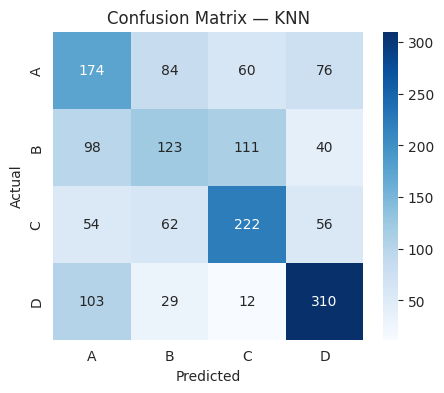

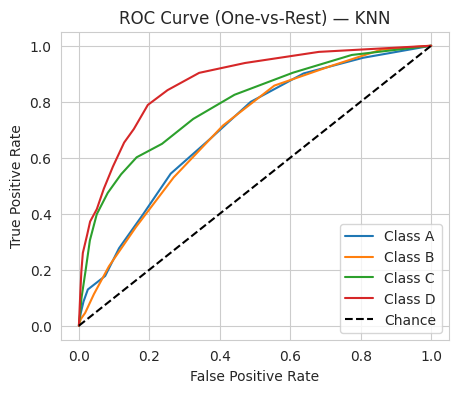

===== Decision Tree =====
              precision    recall  f1-score   support

           A       0.44      0.45      0.45       394
           B       0.40      0.30      0.34       372
           C       0.55      0.54      0.55       394
           D       0.63      0.75      0.68       454

    accuracy                           0.52      1614
   macro avg       0.50      0.51      0.50      1614
weighted avg       0.51      0.52      0.51      1614

Accuracy 0.5223 | Macro-P 0.5041 | Macro-R 0.5106 | Macro-F1 0.5044 | Macro-AUC 0.7648


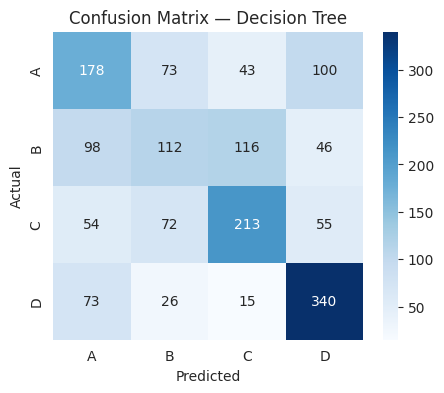

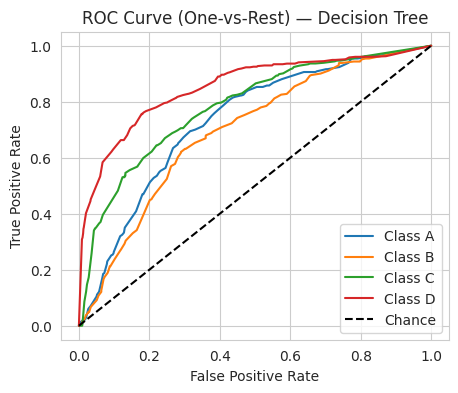

===== Neural Network (MLP) =====
              precision    recall  f1-score   support

           A       0.41      0.40      0.41       394
           B       0.42      0.23      0.30       372
           C       0.51      0.61      0.56       394
           D       0.63      0.76      0.69       454

    accuracy                           0.52      1614
   macro avg       0.49      0.50      0.49      1614
weighted avg       0.50      0.52      0.50      1614

Accuracy 0.5155 | Macro-P 0.4926 | Macro-R 0.5023 | Macro-F1 0.4882 | Macro-AUC 0.7771


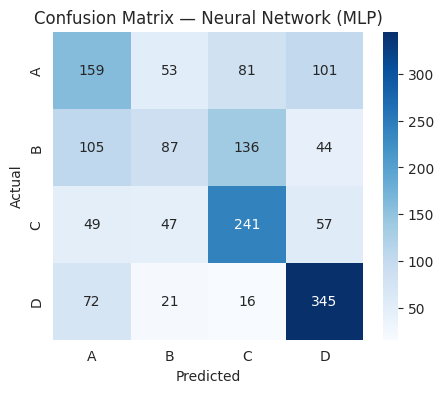

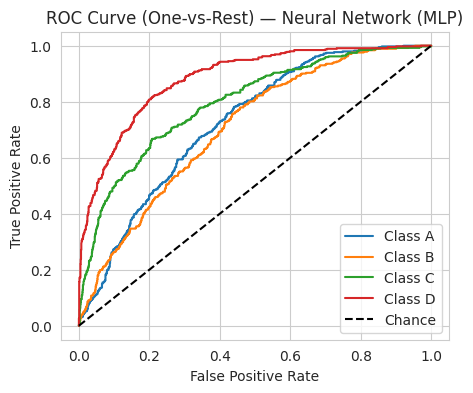

In [ ]:
classes = target_encoder.classes_
y_test_bin = label_binarize(y_test, classes=range(len(classes)))  # for multiclass ROC

results = []
for name, pipe in trained_pipelines.items():
    y_pred = pipe.predict(X_test)  # test predictions
    y_proba = pipe.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec_macro = recall_score(y_test, y_pred, average='macro')
    f1_macro = f1_score(y_test, y_pred, average='macro')  # equal weight per class
    auc_macro = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')  # one-vs-rest AUC
    results.append([name, acc, prec_macro, rec_macro, f1_macro, auc_macro])

    print('=====', name, '=====')
    print(classification_report(y_test, y_pred, target_names=classes))
    print(f'Accuracy {acc:.4f} | Macro-P {prec_macro:.4f} | Macro-R {rec_macro:.4f} | '
          f'Macro-F1 {f1_macro:.4f} | Macro-AUC {auc_macro:.4f}')

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix — {name}')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.show()

    plt.figure(figsize=(5, 4))
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        plt.plot(fpr, tpr, label=f'Class {cls}')
    plt.plot([0, 1], [0, 1], 'k--', label='Chance')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve (One-vs-Rest) — {name}')
    plt.legend()
    plt.show()

In [ ]:
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'MacroPrecision', 'MacroRecall', 'MacroF1', 'MacroAUC'])  # model comparison
results_df = results_df.sort_values('MacroF1', ascending=False).reset_index(drop=True)  # best F1 first
results_df

,Model,Accuracy,MacroPrecision,MacroRecall,MacroF1,MacroAUC
0,Decision Tree,0.522305,0.504075,0.510590,0.504383,0.764819
1,KNN,0.513631,0.502412,0.504635,0.502024,0.765109
2,Neural Network (MLP),0.515489,0.492602,0.502253,0.488206,0.777089
3,Logistic Regression,0.516109,0.496927,0.503388,0.488024,0.763591


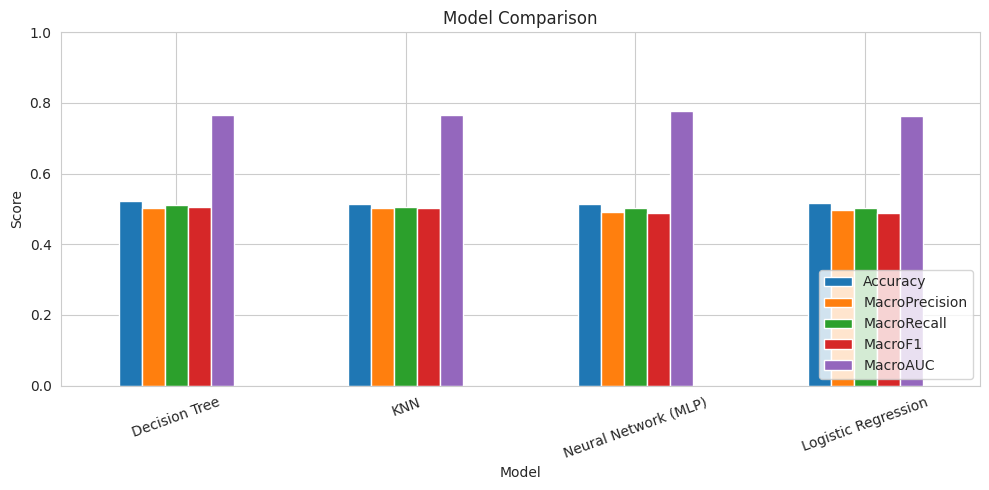

In [ ]:
results_df.set_index('Model')[['Accuracy', 'MacroPrecision', 'MacroRecall', 'MacroF1', 'MacroAUC']].plot(  # compare model scores
    kind='bar', figsize=(10, 5))
plt.title('Model Comparison')
plt.ylabel('Score'); plt.xticks(rotation=20); plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 8. Unsupervised Learning

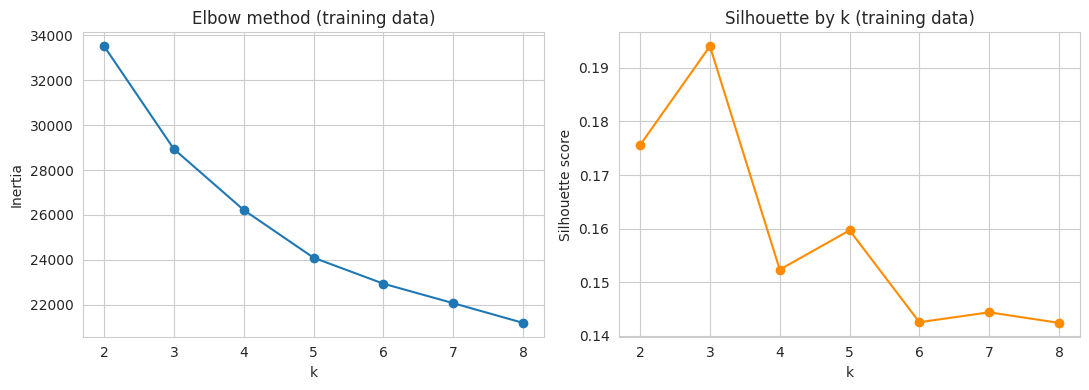

{2: 33504, 3: 28929, 4: 26221, 5: 24102, 6: 22947, 7: 22080, 8: 21204}
{2: np.float64(0.176), 3: np.float64(0.194), 4: np.float64(0.152), 5: np.float64(0.16), 6: np.float64(0.143), 7: np.float64(0.144), 8: np.float64(0.142)}


In [ ]:
shared_pre = make_preprocessor()
X_train_proc = shared_pre.fit_transform(X_train)  # fit preprocessing on train
X_test_proc = shared_pre.transform(X_test)  # transform test the same way

inertia, sil_scores = [], []
k_range = range(2, 9)  # try k = 2 to 8
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_train_proc)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_train_proc, labels))  # cluster quality

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(k_range), inertia, marker='o')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].set_title('Elbow method (training data)')
axes[1].plot(list(k_range), sil_scores, marker='o', color='darkorange')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette score'); axes[1].set_title('Silhouette by k (training data)')
plt.tight_layout()
plt.show()

print(dict(zip(k_range, [round(i) for i in inertia])))
print(dict(zip(k_range, [round(s, 3) for s in sil_scores])))

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)  # final 4 clusters
train_clusters = kmeans.fit_predict(X_train_proc)  # learn clusters
test_clusters = kmeans.predict(X_test_proc)  # assign test clusters

print(np.bincount(train_clusters))
print(np.bincount(test_clusters))

[1405 1197 2081 1771]
[370 281 522 441]


[0.2627981  0.17690849]


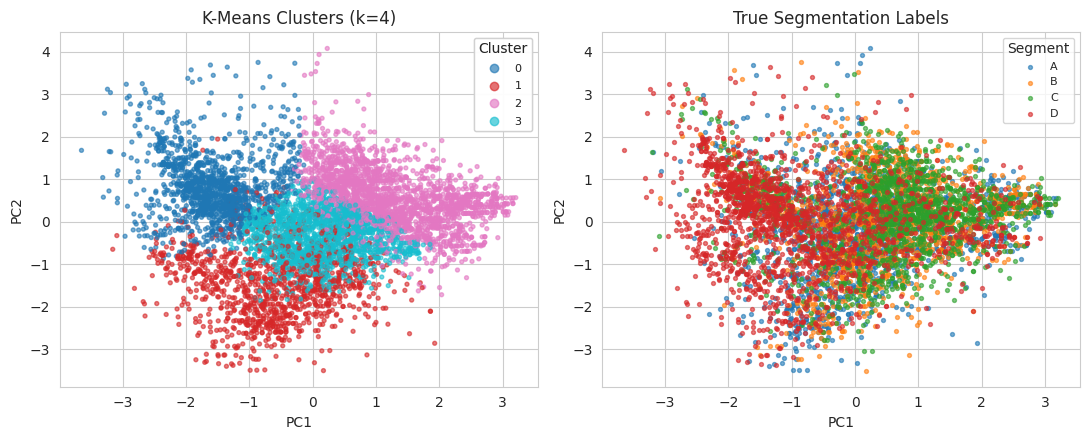

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)  # reduce to 2D
coords = pca.fit_transform(X_train_proc)  # PCA coordinates
print(pca.explained_variance_ratio_)

true_labels_str = target_encoder.inverse_transform(y_train)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
scatter1 = axes[0].scatter(coords[:, 0], coords[:, 1], c=train_clusters, cmap='tab10', s=8, alpha=0.6)
axes[0].set_title('K-Means Clusters (k=4)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
legend1 = axes[0].legend(*scatter1.legend_elements(), title='Cluster', loc='best', fontsize=8)
axes[0].add_artist(legend1)

for cls in target_encoder.classes_:
    mask = true_labels_str == cls  # points from one class
    axes[1].scatter(coords[mask, 0], coords[mask, 1], s=8, alpha=0.6, label=cls)
axes[1].set_title('True Segmentation Labels')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(title='Segment', loc='best', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
sil_train = silhouette_score(X_train_proc, train_clusters)  # train silhouette
sil_test = silhouette_score(X_test_proc, test_clusters)  # test silhouette
ari_test = adjusted_rand_score(y_test, test_clusters)  # ARI score
nmi_test = normalized_mutual_info_score(y_test, test_clusters)  # NMI score

print(sil_train, sil_test, ari_test, nmi_test)

0.15236139497970175 0.15530478398512126 0.09174151644673328 0.09382419342014356


In [ ]:
y_train_arr = np.asarray(y_train)
crosstab = pd.crosstab(
    pd.Series(train_clusters, name='Cluster'),
    pd.Series(target_encoder.inverse_transform(y_train_arr), name='TrueClass')  # back to A-D
)
crosstab

TrueClass,A,B,C,D
Cluster,,,,
0,205,150,187,863
1,351,239,244,363
2,402,633,834,212
3,620,464,311,376


In [ ]:
contingency = pd.crosstab(train_clusters, y_train_arr)
row_ind, col_ind = linear_sum_assignment(-contingency.values)  # best cluster match
cluster_to_class = {int(contingency.index[r]): int(contingency.columns[c]) for r, c in zip(row_ind, col_ind)}
print(cluster_to_class)

mapped_test_pred = np.array([cluster_to_class[c] for c in test_clusters])  # mapped predictions
mapped_acc = accuracy_score(y_test, mapped_test_pred)  # cluster pseudo-accuracy
print(mapped_acc)

{0: 3, 1: 1, 2: 2, 3: 0}
0.4114002478314746
